### Feature Adversaries Attack in PyTorch

__Step 1__: Prepare an MNIST Classifier using pytorch framework.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from art.attacks.evasion import FeatureAdversariesPyTorch
from art.estimators.classification import PyTorchClassifier
from art.utils import load_mnist


# Step 1: Load the MNIST dataset

(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_mnist()

# Step 1a: Swap axes to PyTorch's NCHW format

x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)

# Step 2: Create the model

model = nn.Sequential(
    nn.Conv2d(1, 4, 5), nn.ReLU(), nn.MaxPool2d(2, 2), 
    nn.Conv2d(4, 10, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
    nn.Flatten(), 
    nn.Linear(4*4*10, 100),    
    nn.Linear(100, 10)
)
# Step 2a: Define the loss function and the optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Step 3: Create the ART classifier

classifier = PyTorchClassifier(
    model=model,
    clip_values=(min_pixel_value, max_pixel_value),
    loss=criterion,
    optimizer=optimizer,
    input_shape=(1, 28, 28),
    nb_classes=10,
)

# Step 4: Train the ART classifier

classifier.fit(x_train, y_train, batch_size=64, nb_epochs=3)

# Step 5: Evaluate the ART classifier on benign test examples

predictions = classifier.predict(x_test)
accuracy = np.sum(np.argmax(predictions, axis=1) == np.argmax(y_test, axis=1)) / len(y_test)
print("Accuracy on benign test examples: {}%".format(accuracy * 100))

/home/nura-kawa/Projects/localized-classmap/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nura-kawa/Projects/localized-classmap/env/lib/python3.12/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


Accuracy on benign test examples: 96.2%


In [2]:
# # Explanation
# from localized_classmap import plotExplanations
# # source localized classmap
# exec(open('localized_classmap.py').read())

# plotExplanations(model=classifier,
#                  X=x_test,
#                  y=np.argmax(y_test, axis=1),
#                  k=40,
#                  cl=3,
#                  annotate=True,
#                  pytorch=True)

---

## PGD variant of Feature Adversaries


In [3]:
# Step 5: prepare a batch of source and guide images
valid = np.argmax(y_test, axis=1)[:100] != np.argmax(y_test, axis=1)[100:200]
source = x_test[:100][valid][:32]
guide = x_test[100:200][valid][:32]

In [4]:
# Step 6: Generate adversarial test examples
attack = FeatureAdversariesPyTorch(
    classifier,
    layer=7,
    delta=35/255, #35/255
    optimizer=None,
    step_size=1/255,
    max_iter=100,
)
x_adv = attack.generate(source, guide)

# Step 7: Evaluate the ART classifier on adversarial test examples

predictions = classifier.predict(x_adv)
y_adv = y_test[:100][valid][:32]

accuracy = np.sum(np.argmax(predictions, axis=1) == np.argmax(y_adv, axis=1)) / len(y_adv)

dim = tuple(range(1, len(source.shape)))
pert = np.mean(np.amax(np.abs(source - x_adv), axis=dim))
print("Accuracy on adversarial test batch: {}%".format(accuracy * 100))
print("Average perturbation: {}%".format(pert))

Feature Adversaries PyTorch: 100%|██████████| 100/100 [00:00<00:00, 176.29it/s]

Accuracy on adversarial test batch: 6.25%
Average perturbation: 0.13725492358207703%


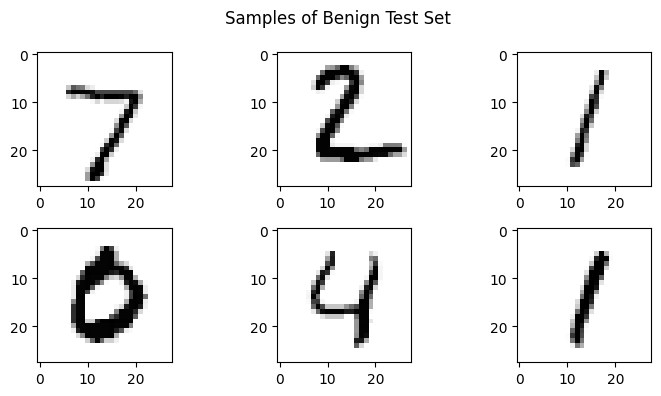

In [5]:
# Step 8: Inspect results


# Visualize Benign Examples

num_row = 2
num_col = 3

# plot images: atypical examples of class 9
fig, axes = plt.subplots(num_row, num_col,
                         figsize=(2.5*num_col,2*num_row))
for i in range(6):
    ax = axes[i//num_col, i%num_col]
    img = x_test[i,...].squeeze()
    ax.imshow(img, cmap='Greys')
fig.suptitle('Samples of Benign Test Set')
plt.tight_layout()
plt.show()

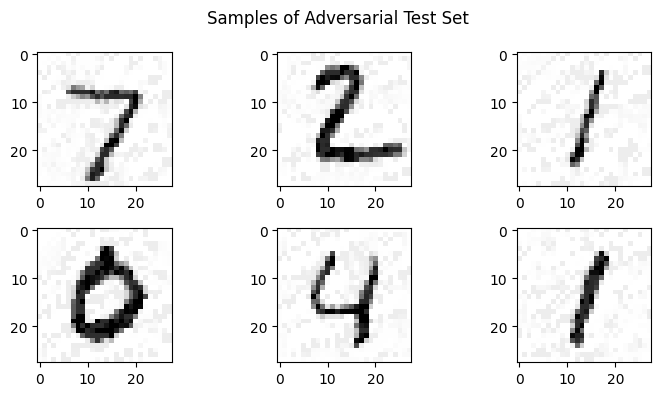

In [6]:
# Step 8: Inspect results


# Visualize Adversarial Examples

num_row = 2
num_col = 3

# plot images: atypical examples of class 9
fig, axes = plt.subplots(num_row, num_col,
                         figsize=(2.5*num_col,2*num_row))
for i in range(6):
    ax = axes[i//num_col, i%num_col]
    img = x_adv[i,...].squeeze()
    ax.imshow(img, cmap='Greys')
fig.suptitle('Samples of Adversarial Test Set')
plt.tight_layout()
plt.show()

Localized Classmap with Adversarial Examples

Adversarial accuracy: 0.3333 %
Searching for 40 nearest neighbors for 10032 points. This could take some time!
Nearest neighbor search complete !
(array([10000, 10017, 10026]),)
[10000]


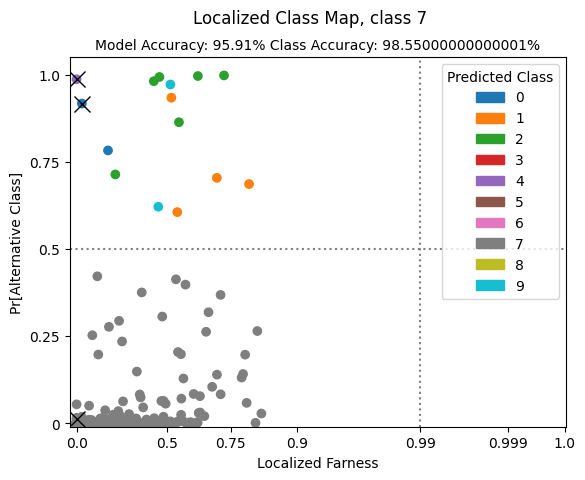

In [7]:
# source localized classmap
exec(open('localized_classmap.py').read())

# Model Explanation

plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=40,
    cl=7,
    annotate=True,
    pytorch=True)

Adversarial accuracy: 0.0 %
Searching for 40 nearest neighbors for 10032 points. This could take some time!
Nearest neighbor search complete !
(array([10007, 10009, 10012, 10016, 10020]),)
[10007]


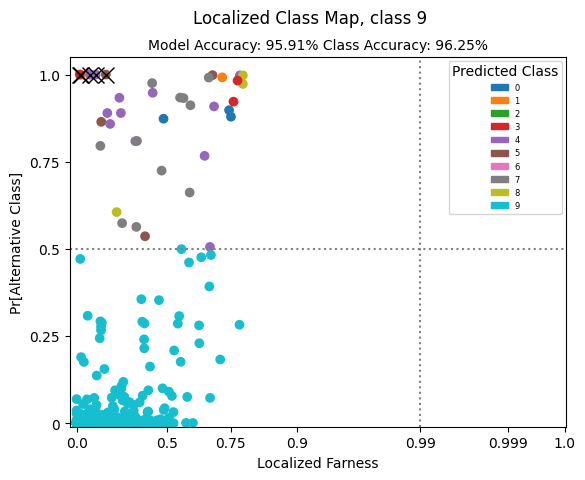

In [8]:
# source localized classmap
exec(open('localized_classmap.py').read())

# Model Explanation

plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=40,
    cl=9,
    annotate=True,
    pytorch=True)

In [ ]:
# Let's visualize these examples

# Visualize Adversarial Examples

num_row = 2
num_col = 3

# plot images: atypical examples of class 9
fig, axes = plt.subplots(num_row, num_col,
                         figsize=(2.5*num_col,2*num_row))

#indices = [72, 85, 91, 95, 96, 98]

for i in range(6):
    ax = axes[i//num_col, i%num_col]
    #ax = axes[i]
    img = x_adv[16+i,...].squeeze()
    ax.imshow(img, cmap='Greys')
fig.suptitle('Samples of Adversarial Test Set')
plt.tight_layout()
plt.show()

In [51]:
model_preds = classifier.predict(x_adv)


In [ ]:
accuracy = np.sum(np.argmax(model_preds, axis=1) == np.argmax(y_adv, axis=1)) / len(y_adv)
accuracy

In [ ]:
i = [20]

abc = [20, 333, 33]

i in abc


## Unconstrained variant of Feature Adversaries

This variant approximates the original hard constraint problem of the paper. Any available PyTorch optimizer can be used. We will use Adam as a good default one.


In [ ]:
# Step 6: Generate adversarial test examples
attack = FeatureAdversariesPyTorch(
    classifier,
    layer=7,
    delta=61/255,
    optimizer=optim.Adam,
    optimizer_kwargs={"lr": 0.01},
    lambda_=1.0,
    max_iter=100,
    random_start=True
)
x_test_adv_unconstrained = attack.generate(source, guide)

# Step 7: Evaluate the ART classifier on adversarial test examples

predictions = classifier.predict(x_adv)
accuracy = np.sum(np.argmax(predictions, axis=1) == np.argmax(y_test[:100][valid][:32], axis=1)) / len(y_test[:100][valid][:32])

dim = tuple(range(1, len(source.shape)))
pert = np.mean(np.amax(np.abs(source - x_adv), axis=dim))
print("Accuracy on adversarial test batch: {}%".format(accuracy * 100))
print("Average perturbation: {}%".format(pert))

In [ ]:
# Visualize Adversarial Examples

num_row = 2
num_col = 3

# plot images: atypical examples of class 9
fig, axes = plt.subplots(num_row, num_col,
                         figsize=(2.5*num_col,2*num_row))
for i in range(6):
    ax = axes[i//num_col, i%num_col]
    img = x_test_adv_unconstrained[i,...].squeeze()
    ax.imshow(img, cmap='Greys')
fig.suptitle('Samples of Adversarial Test Set')
plt.tight_layout()
plt.show()

In [78]:
x_adv = np.load('data/examples-feature-adversaries.npy')
y_test_adv = np.load('data/labels-feature-adversaries.npy')

In [ ]:
np.argmax(y_test_adv,axis=1)[6:12]

In [ ]:
# Visualize Adversarial Examples

num_row = 2
num_col = 3

# plot images: atypical examples of class 9
fig, axes = plt.subplots(num_row, num_col,
                         figsize=(2.5*num_col,2*num_row))
for i in range(6):
    ax = axes[i//num_col, i%num_col]
    img = x_adv[6+i,...].squeeze()
    ax.imshow(img, cmap='Greys')
fig.suptitle('Samples of Adversarial Test Set')
plt.tight_layout()
plt.show()

In [ ]:
x_test.shape